In [8]:
import io
import numpy as np
import pandas as pd
from google.colab import files

# 1. Ouvrir la fenêtre de téléchargement dans le navigateur
print("Veuillez sélectionner votre fichier 'global_power_plant_database.csv' :")
uploaded = files.upload()

# 2. Récupérer le nom du fichier chargé automatiquement
file_name = list(uploaded.keys())[0]

# 3. Importer le fichier dans Pandas
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

# 4. Afficher les résultats pour vérification
print("\n--- IMPORTATION RÉUSSIE ---")
print(f"Fichier chargé : {file_name}")
print(f"Dimensions de la base : {df.shape[0]} lignes et {df.shape[1]} colonnes.\n")

print("--- APERÇU DES 5 PREMIÈRES LIGNES ---")
print(df.head())

print("\n--- VALEURS MANQUANTES PAR COLONNE ---")
print(df.isnull().sum())
# 1. Charger la dernière version du fichier (ici la version 4 générée par votre dernier essai)
df = pd.read_csv("global_power_plant_database.csv", low_memory=False)

print("--- DÉBUT DU NETTOYAGE ---")

# --- ÉTAPE 1 : TRAITEMENT DES VALEURS MANQUANTES ---

# Remplacer les valeurs textuelles manquantes (NaN) par 'Unknown' (Inconnu)
colonnes_texte = ["other_fuel1", "other_fuel2", "other_fuel3", "owner"]
for col in colonnes_texte:
    df[col] = df[col].fillna("Unknown")

# Remplacer les valeurs numériques manquantes (la production d'énergie gwh) par 0
# (Si aucune donnée n'est fournie, on part du principe que la production n'est pas enregistrée ou nulle)
colonnes_generation = [
    "generation_gwh_2013",
    "generation_gwh_2014",
    "generation_gwh_2015",
    "generation_gwh_2016",
    "generation_gwh_2017",
    "generation_gwh_2018",
    "generation_gwh_2019",
]
for col in colonnes_generation:
    df[col] = df[col].fillna(0)

# Pour l'année de mise en service (commissioning_year), on remplace par la valeur médiane
annee_mediane = df["commissioning_year"].median()
df["commissioning_year"] = df["commissioning_year"].fillna(annee_mediane)


# --- ÉTAPE 2 : CONVERSION EN TYPES NUMÉRIQUES AVEC NUMPY ---

# Résoudre le problème des types mixtes en forçant la conversion en numérique
# 'errors=coerce' transformera les textes invalides en NaN, qu'on remplacera ensuite par 0
df["estimated_generation_gwh_2017"] = pd.to_numeric(
    df["estimated_generation_gwh_2017"], errors="coerce"
).fillna(0)

# Utiliser NumPy pour optimiser et convertir les types de données
df["capacity_mw"] = df["capacity_mw"].astype(np.float64)
df["commissioning_year"] = df["commissioning_year"].astype(
    np.int32
)  # Une année est un entier

for col in colonnes_generation:
    df[col] = df[col].astype(np.float64)


# --- ÉTAPE 3 : VÉRIFICATION FINALE ---
print("\n--- NETTOYAGE TERMINÉ ---")
print("Nombre de valeurs manquantes restantes pour les colonnes clés :")
print(df[["capacity_mw", "commissioning_year", "generation_gwh_2017"]].isnull().sum())

print("\nTypes des colonnes après modification :")
print(df[["capacity_mw", "commissioning_year", "generation_gwh_2017"]].dtypes)

Veuillez sélectionner votre fichier 'global_power_plant_database.csv' :


Saving global_power_plant_database.csv to global_power_plant_database (4).csv


/tmp/ipykernel_2420/4278541134.py:14: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(io.BytesIO(uploaded[file_name]))



--- IMPORTATION RÉUSSIE ---
Fichier chargé : global_power_plant_database (4).csv
Dimensions de la base : 34936 lignes et 36 colonnes.

--- APERÇU DES 5 PREMIÈRES LIGNES ---
  country country_long                                              name  \
0     AFG  Afghanistan      Kajaki Hydroelectric Power Plant Afghanistan   
1     AFG  Afghanistan                                      Kandahar DOG   
2     AFG  Afghanistan                                      Kandahar JOL   
3     AFG  Afghanistan     Mahipar Hydroelectric Power Plant Afghanistan   
4     AFG  Afghanistan  Naghlu Dam Hydroelectric Power Plant Afghanistan   

      gppd_idnr  capacity_mw  latitude  longitude primary_fuel other_fuel1  \
0  GEODB0040538         33.0    32.322    65.1190        Hydro         NaN   
1    WKS0070144         10.0    31.670    65.7950        Solar         NaN   
2    WKS0071196         10.0    31.623    65.7920        Solar         NaN   
3  GEODB0040541         66.0    34.556    69.4787        

In [10]:
import pandas as pd
import numpy as np

# (Optionnel) Si vous recommencez dans un nouveau notebook, rechargez votre fichier nettoyé :
df = pd.read_csv("global_power_plant_database (4).csv", low_memory=False)

print("==================================================")
print("1. STATISTIQUES CLÉS DES COLONNES NUMÉRIQUES")
print("==================================================\n")

# Sélectionner les colonnes numériques principales pour l'analyse
colonnes_analyses = ['capacity_mw', 'commissioning_year', 'generation_gwh_2017']

# La méthode .describe() calcule automatiquement la moyenne (mean),
# l'écart-type (std), le min, le max et les quartiles (dont la médiane à 50%)
statistiques = df[colonnes_analyses].describe()

# Pour afficher précisément la médiane sous son nom, on peut l'ajouter manuellement
statistiques.loc['median'] = df[colonnes_analyses].median()

# Affichage des statistiques arrondies à 2 décimales
print(statistiques.loc[['mean', 'median', 'std', 'min', 'max']].round(2))


print("\n==================================================")
print("2. RÉPARTITION DES CENTRALES PAR TYPE DE COMBUSTIBLE")
print("==================================================\n")

# Compter le nombre de centrales pour chaque type de combustible principal
repartition_fuel = df['primary_fuel'].value_counts()
print("Top des combustibles les plus utilisés dans le monde :")
print(repartition_fuel)

# Afficher également en pourcentage
print("\nRépartition en pourcentage :")
print((df['primary_fuel'].value_counts(normalize=True) * 100).round(2).astype(str) + '%')


print("\n==================================================")
print("3. RÉPARTITION DES CENTRALES PAR PAYS (TOP 10)")
print("==================================================\n")

# Compter le nombre de centrales par pays (en utilisant le nom long du pays)
repartition_pays = df['country_long'].value_counts().head(10)
print("Les 10 pays qui possèdent le plus de centrales électriques :")
print(repartition_pays)


print("\n==================================================")
print("4. CROISEMENT : COMBUSTIBLE PAR PAYS (TOP 5 PAYS)")
print("==================================================\n")

# Étape avancée : On filtre sur les 5 plus grands pays pour voir leurs combustibles préférés
top_5_pays = df['country_long'].value_counts().head(5).index

# On utilise crosstab pour créer un tableau croisé (croisement Pays x Combustible)
tableau_croise = pd.crosstab(df['country_long'], df['primary_fuel'])
tableau_croise_top5 = tableau_croise.loc[top_5_pays]

print("Nombre de centrales par type de combustible pour les 5 plus grands pays :")
print(tableau_croise_top5)

1. STATISTIQUES CLÉS DES COLONNES NUMÉRIQUES

        capacity_mw  commissioning_year  generation_gwh_2017
mean         163.36             1997.41               661.83
median        16.74             2007.00                17.88
std          489.64               23.40              2369.30
min            1.00             1896.00              -934.94
max        22500.00             2020.00             36448.64

2. RÉPARTITION DES CENTRALES PAR TYPE DE COMBUSTIBLE

Top des combustibles les plus utilisés dans le monde :
primary_fuel
Solar             10665
Hydro              7156
Wind               5344
Gas                3998
Coal               2330
Oil                2320
Biomass            1430
Waste              1068
Nuclear             195
Geothermal          189
Storage             135
Other                43
Cogeneration         41
Petcoke              12
Wave and Tidal       10
Name: count, dtype: int64

Répartition en pourcentage :
primary_fuel
Solar             30.53%
Hydro      

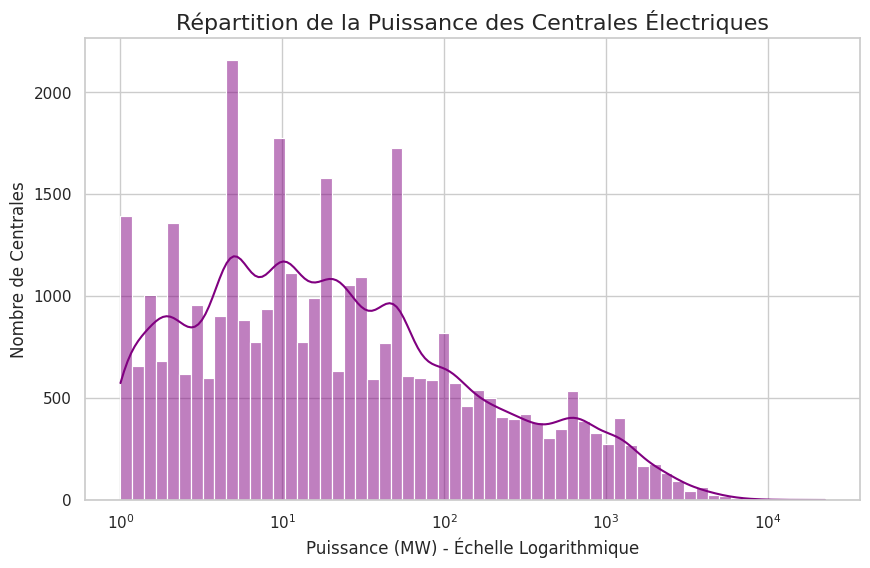

/tmp/ipykernel_2420/2373453801.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, y='primary_fuel', order=order, palette='Spectral')


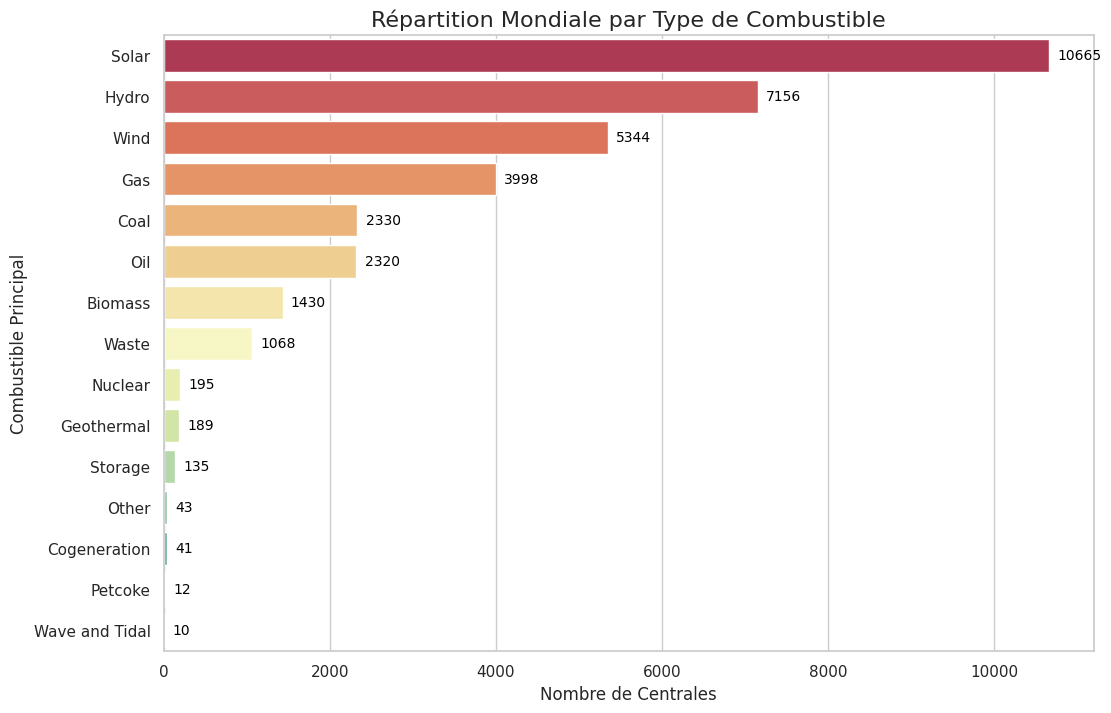

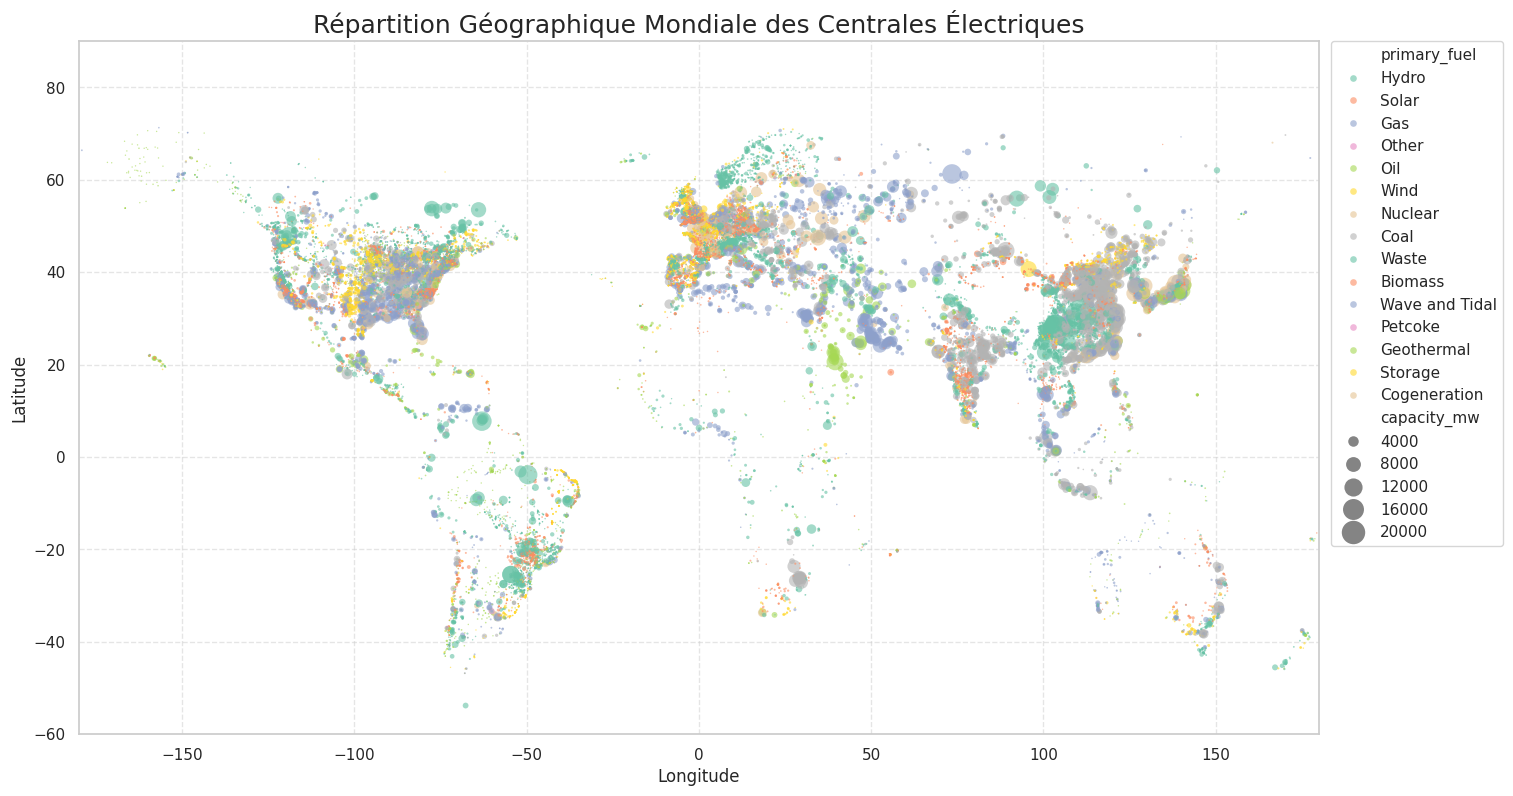

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- Configuration des graphiques Seaborn ---
# On applique un style propre et professionnel
sns.set_theme(style="whitegrid", palette="Spectral")

# --- 1. Visualisation de la Répartition de la Puissance (capacity_mw) ---
# Un histogramme pour voir la fréquence des tailles de centrales.
# On utilise une échelle logarithmique sur l'axe X car les puissances sont très dispersées.

plt.figure(figsize=(10, 6))
sns.histplot(df['capacity_mw'], kde=True, color='purple', log_scale=True)
plt.title("Répartition de la Puissance des Centrales Électriques", fontsize=16)
plt.xlabel("Puissance (MW) - Échelle Logarithmique", fontsize=12)
plt.ylabel("Nombre de Centrales", fontsize=12)
plt.show()

# --- 2. Visualisation des Combustibles les Plus Utilisés ---
# Un diagramme en barres horizontales pour classer les combustibles principaux.

plt.figure(figsize=(12, 8))
# Compter et classer les types de combustibles
order = df['primary_fuel'].value_counts().index
ax = sns.countplot(data=df, y='primary_fuel', order=order, palette='Spectral')
plt.title("Répartition Mondiale par Type de Combustible", fontsize=16)
plt.xlabel("Nombre de Centrales", fontsize=12)
plt.ylabel("Combustible Principal", fontsize=12)

# Ajouter des étiquettes de valeur sur chaque barre pour plus de clarté
for i, p in enumerate(ax.patches):
    text = f"{int(p.get_width())}"
    ax.annotate(text, (p.get_width() + 100, p.get_y() + p.get_height()/2),
                ha='left', va='center', fontsize=10, color='black')
plt.show()

# --- 3. Visualisation Géographique Mondiale ---
# Un nuage de points où :
# - L'axe X = Longitude, Axe Y = Latitude (une projection cartographique basique)
# - La couleur = Type de combustible (primary_fuel)
# - La taille du point = Puissance (capacity_mw)

# Étape 1 : Créer une projection de base pour délimiter le monde
map_projection_url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.shp"
# Si geopandas était installé, on pourrait charger une vraie carte.
# Ici, nous allons simuler les continents en utilisant les données brutes.

# Étape 2 : Créer le graphique
plt.figure(figsize=(16, 9))

# On filtre les points sans coordonnées (juste au cas où)
df_geo = df.dropna(subset=['latitude', 'longitude'])

# Scatterplot géographique
geo_plot = sns.scatterplot(
    data=df_geo,
    x='longitude',
    y='latitude',
    hue='primary_fuel',  # Couleur par combustible
    size='capacity_mw',  # Taille par puissance
    sizes=(1, 500),      # Plage de tailles des points
    palette='Set2',      # Palette de couleurs distinctes
    alpha=0.6,           # Transparence pour voir les superpositions
    edgecolor='none'     # Enlever le bord des points
)

# Configuration du graphique
plt.title("Répartition Géographique Mondiale des Centrales Électriques", fontsize=18)
plt.xlabel("Longitude", fontsize=12)
plt.ylabel("Latitude", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Définir les limites pour cadrer la carte mondiale
plt.xlim(-180, 180)
plt.ylim(-60, 90)

# Personnaliser les légendes pour qu'elles ne masquent pas les points
plt.legend(bbox_to_anchor=(1.01, 1), loc=2, borderaxespad=0., markerscale=0.8)
plt.show()

In [12]:
import pandas as pd
import numpy as np

# 1. Recharger le fichier propre
df = pd.read_csv("global_power_plant_database.csv", low_memory=False)

# Nettoyage rapide des colonnes cibles pour éviter les NaN dans le calcul matriciel
df['capacity_mw'] = df['capacity_mw'].fillna(df['capacity_mw'].median())
df['latitude'] = df['latitude'].fillna(df['latitude'].mean())
df['longitude'] = df['longitude'].fillna(df['longitude'].mean())

# Encodage numérique du carburant (remplacé par la capacité moyenne du groupe)
fuel_means = df.groupby('primary_fuel')['capacity_mw'].transform('mean')
df['fuel_encoded'] = fuel_means

# 2. Extraction des attributs sous forme de Matrice de données (A)
attributs = ['capacity_mw', 'latitude', 'longitude', 'fuel_encoded']
A_brute = df[attributs].to_numpy()

# 3. Standardisation de la matrice (Centrer-Réduire)
# Essentiel pour que la latitude/longitude n'écrase pas la capacité
A_centree = A_brute - np.mean(A_brute, axis=0)
A_standardisee = A_centree / np.std(A_brute, axis=0)

# 4. OPÉRATION MATRICIELLE : Calcul de la Matrice de Covariance (C)
n = A_standardisee.shape[0]
C = (1 / (n - 1)) * np.dot(A_standardisee.T, A_standardisee)

print("==================================================")
print("1. MATRICE DE COVARIANCE (C)")
print("==================================================")
df_cov = pd.DataFrame(C, index=attributs, columns=attributs)
print(df_cov.round(4))

# 5. OPÉRATION MATRICIELLE : Extraction des Valeurs Propres et Vecteurs Propres
valeurs_propres, vecteurs_propres = np.linalg.eig(C)

# Trier du plus grand au plus petit (importance décroissante)
idx = valeurs_propres.argsort()[::-1]
valeurs_propres = valeurs_propres[idx]
vecteurs_propres = vecteurs_propres[:, idx]

print("\n==================================================")
print("2. VALEURS PROPRES ET VARIANCE EXPLIQUÉE")
print("==================================================")
variance_expliquee = (valeurs_propres / np.sum(valeurs_propres)) * 100
for i, (val, var) in enumerate(zip(valeurs_propres, variance_expliquee)):
    print(f"Axe {i+1} (Valeur Propre = {val:.4f}) : explique {var:.2f}% de l'information.")

print("\n==================================================")
print("3. VECTEURS PROPRES (COMPOSANTES PRINCIPALES)")
print("==================================================")
df_vecteurs = pd.DataFrame(vecteurs_propres, index=attributs, columns=[f'Axe_{i+1}' for i in range(4)])
print(df_vecteurs.round(4))

1. MATRICE DE COVARIANCE (C)
              capacity_mw  latitude  longitude  fuel_encoded
capacity_mw        1.0000   -0.0132     0.1515        0.5287
latitude          -0.0132    1.0000    -0.0684       -0.0240
longitude          0.1515   -0.0684     1.0000        0.1477
fuel_encoded       0.5287   -0.0240     0.1477        1.0000

2. VALEURS PROPRES ET VARIANCE EXPLIQUÉE
Axe 1 (Valeur Propre = 1.6067) : explique 40.17% de l'information.
Axe 2 (Valeur Propre = 1.0269) : explique 25.67% de l'information.
Axe 3 (Valeur Propre = 0.8952) : explique 22.38% de l'information.
Axe 4 (Valeur Propre = 0.4712) : explique 11.78% de l'information.

3. VECTEURS PROPRES (COMPOSANTES PRINCIPALES)
               Axe_1   Axe_2   Axe_3   Axe_4
capacity_mw  -0.6638  0.1677 -0.1739  0.7078
latitude      0.0786  0.8735  0.4802 -0.0153
longitude    -0.3362 -0.4304  0.8377 -0.0075
fuel_encoded -0.6634  0.1537 -0.1936 -0.7062


In [13]:
import pandas as pd
import numpy as np

# Rechargement de vos données
df = pd.read_csv("global_power_plant_database.csv", low_memory=False)

# 1. Définition des conditions complexes avec NumPy
conditions = [
    (df['capacity_mw'] >= 1000) & (df['commissioning_year'] >= 2000),
    (df['capacity_mw'] >= 1000) & (df['commissioning_year'] < 2000),
    (df['capacity_mw'] < 1000) & (df['primary_fuel'] == 'Hydro'),
    (df['capacity_mw'] < 1000) & (df['primary_fuel'] != 'Hydro')
]

# 2. Définition des choix correspondants
choix = [
    'Géant Moderne (Post-2000)',
    'Géant Historique (Pré-2000)',
    'Petite/Moyenne Centrale Hydro',
    'Standard Autre'
]

# 3. Application instantanée de NumPy sur le DataFrame Pandas
df['categorie_centrale'] = np.select(conditions, choix, default='Non classé')

print(df['categorie_centrale'].value_counts())

categorie_centrale
Standard Autre                   26410
Petite/Moyenne Centrale Hydro     6908
Géant Moderne (Post-2000)          674
Géant Historique (Pré-2000)        490
Non classé                         454
Name: count, dtype: int64


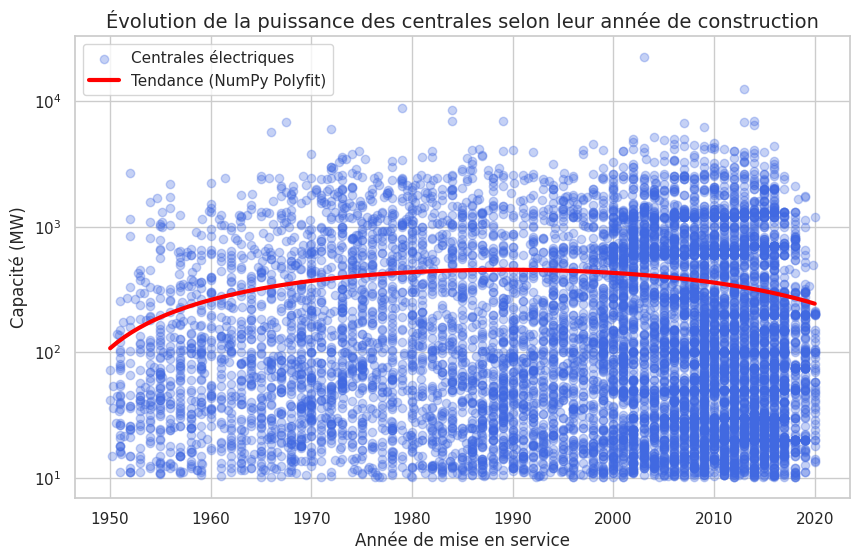

In [17]:
import matplotlib.pyplot as plt

# Nettoyage rapide pour éliminer les valeurs manquantes sur les axes étudiés
df_sub = df.dropna(subset=['commissioning_year', 'capacity_mw'])
# On filtre pour l'exemple sur les centrales après 1950 et de taille significative
df_sub = df_sub[(df_sub['commissioning_year'] > 1950) & (df_sub['capacity_mw'] > 10)]

# Extraction des données sous forme de tableaux NumPy
x = df_sub['commissioning_year'].to_numpy()
y = df_sub['capacity_mw'].to_numpy()

# --- MAGIE DE NUMPY : Calcul de la courbe de tendance ---
# np.polyfit calcule les coefficients de la courbe (ici degré 2 = parabole)
coefficients = np.polyfit(x, y, deg=2)

# np.linspace crée 100 points régulièrement espacés entre l'année min et max
x_tendance = np.linspace(x.min(), x.max(), 100)

# np.polyval calcule les valeurs de Y correspondantes pour dessiner la courbe lisse
y_tendance = np.polyval(coefficients, x_tendance)

# --- VISUALISATION ---
plt.figure(figsize=(10, 6))

# 1. Dessiner les vraies centrales (les points bleus)
plt.scatter(x, y, alpha=0.3, color='royalblue', label='Centrales électriques')

# 2. Dessiner la courbe de tendance générée par NumPy (la ligne rouge)
plt.plot(x_tendance, y_tendance, color='red', linewidth=3, label='Tendance (NumPy Polyfit)')

plt.title("Évolution de la puissance des centrales selon leur année de construction", fontsize=14)
plt.xlabel("Année de mise en service", fontsize=12)
plt.ylabel("Capacité (MW)", fontsize=12)
plt.yscale('log') # Échelle log pour mieux voir la dispersion
plt.legend()
plt.show()
# Conversion d'une colonne Pandas en vecteur NumPy pur
capacites_matrice = df['capacity_mw'].to_numpy()

# Maintenant, vous pouvez utiliser toutes les fonctions mathématiques ultra-rapides de NumPy
puissance_totale = np.sum(capacites_matrice)
puissance_logarithmique = np.log1p(capacites_matrice) # Évite l'erreur si la valeur est 0

In [16]:
# Conversion d'une colonne Pandas en vecteur NumPy pur
capacites_matrice = df['capacity_mw'].to_numpy()

# Maintenant, vous pouvez utiliser toutes les fonctions mathématiques ultra-rapides de NumPy
puissance_totale = np.sum(capacites_matrice)
puissance_logarithmique = np.log1p(capacites_matrice) # Évite l'erreur si la valeur est 0